In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("RELEVAN_BERITA_SAHAM_FIX_BANGET.csv")
df['tanggal'] = pd.to_datetime(df['tanggal'])
df['year'] = df['tanggal'].dt.year
df_eda = df[(df['year'] >= 2022) & (df['year'] <= 2024)]

print(df_eda['year'].value_counts().sort_index())


year
2022    558
2023    489
2024    464
Name: count, dtype: int64


In [ ]:
df.head()

,Unnamed: 0,tanggal,kategori,judul,url,konten,is_stock_related,konten_clean,year
0,0,2022-01-01,ekonomi,Jaksa Agung Puji Erick Thohir Bantu Bongkar Ko...,https://finance.detik.com/moneter/d-5880248/ja...,Jaksa Agung Burhanuddin memberikan pujian kepa...,True,jaksa agung burhanuddin puji menteri badan usa...,2022
1,1,2022-01-02,ekonomi,Aturan Harga hingga Penyaluran Premium Diromba...,https://finance.detik.com/energi/d-5881226/atu...,Presiden Joko Widodo (Jokowi) telah mengeluark...,True,presiden joko widodo jokowi keluar atur presid...,2022
2,2,2022-01-02,ekonomi,Presiden Joko Widodo (Jokowi) telah mengeluark...,https://finance.detik.com/energi/d-5881226/atu...,Presiden Joko Widodo (Jokowi) telah mengeluark...,True,presiden joko widodo jokowi keluar atur presid...,2022
3,3,2022-01-03,ekonomi,"Genjot Bisnis Data Center, Telkom Ambil Alih S...",https://finance.detik.com/bursa-dan-valas/d-58...,PT Telkom Indonesia (Persero) Tbk (TLKM) menga...,True,telkom indonesia persero tbk tlkm ambil alih s...,2022
4,4,2022-01-04,ekonomi,Ini Pesan Penting Luhut buat OJK,https://finance.detik.com/moneter/d-5884263/in...,Menteri Koordinator Kemaritiman dan Investasi ...,True,menteri koordinator maritim investasi luhut bi...,2022


# Distribusi Jumlah Berita per Tahun (2022-2024)

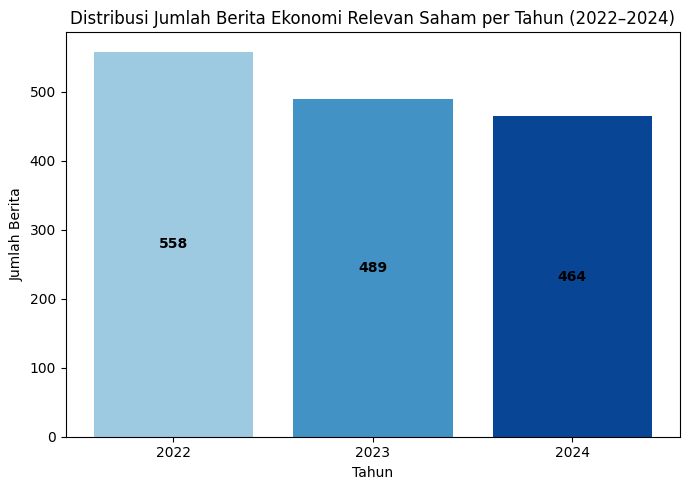

In [ ]:
news_per_year = df_eda['year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 5))

bars = ax.bar(
    news_per_year.index.astype(str),
    news_per_year.values,
    color = ['#9ecae1', '#4292c6', '#084594']
)

ax.set_xlabel("Tahun")
ax.set_ylabel("Jumlah Berita")
ax.set_title("Distribusi Jumlah Berita Ekonomi Relevan Saham per Tahun (2022–2024)")

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


# Analisis Frekuensi Kata & Word Cloud

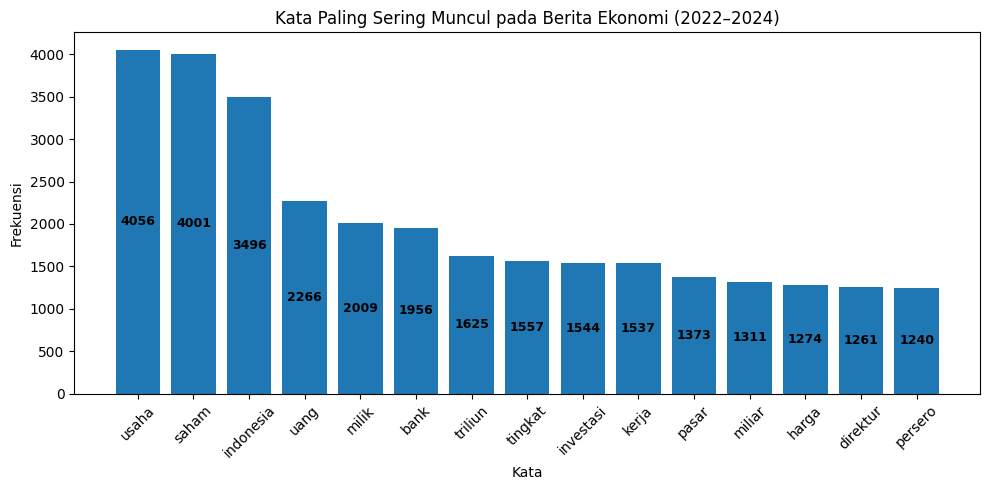

In [ ]:
from collections import Counter
import re
import pandas as pd
import matplotlib.pyplot as plt

text = " ".join(df_eda['konten_clean'].dropna().astype(str))

text = text.lower()
text = re.sub(r'[^a-zA-Z\s]', '', text)

words = text.split()
word_freq = Counter(words)

common_words = word_freq.most_common(15)
freq_df = pd.DataFrame(common_words, columns=['Kata', 'Frekuensi'])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(freq_df['Kata'], freq_df['Frekuensi'])

ax.set_xlabel("Kata")
ax.set_ylabel("Frekuensi")
ax.set_title("Kata Paling Sering Muncul pada Berita Ekonomi (2022–2024)")
plt.xticks(rotation=45)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height / 2,
        f'{int(height)}',
        ha='center',
        va='center',
        fontsize=9,
        fontweight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()

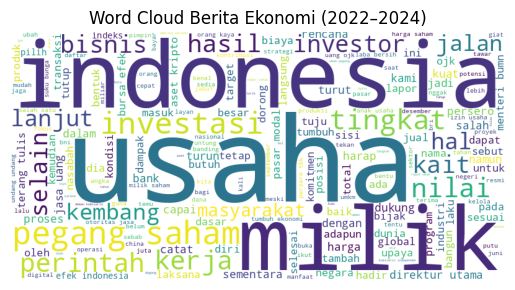

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud Berita Ekonomi (2022–2024)")
plt.show()


# Distribusi Sentimen per Tahun

In [ ]:
df_sentimen = pd.read_csv("DATA_GABUNGAN_SAHAM_DAN_SENTIMEN_AFTER_SIDANG (2).csv")
df_sentimen.tail()

,Unnamed: 0,tanggal,Terakhir,Pembukaan,Tertinggi,Terendah,Vol.,Perubahan%,avg_sentiment,prop_pos,prop_neg,prop_neu,max_impact
717,720,2024-12-20,698387.0,698017.0,703240.0,693158.0,1.457000e+10,0.09,0.000000,0.000000,0.0,1.000000,netral
718,721,2024-12-23,709644.0,703753.0,709644.0,703573.0,1.387000e+10,1.61,0.666667,0.666667,0.0,0.333333,positif
719,722,2024-12-24,706575.0,711564.0,712058.0,706375.0,1.106000e+10,-0.43,0.000000,0.000000,0.0,1.000000,netral
720,723,2024-12-27,703657.0,707338.0,710027.0,702471.0,1.443000e+10,-0.41,0.000000,0.000000,0.0,1.000000,netral
721,724,2024-12-30,707990.0,702678.0,707990.0,699307.0,1.597000e+10,0.62,0.500000,0.500000,0.0,0.500000,positif


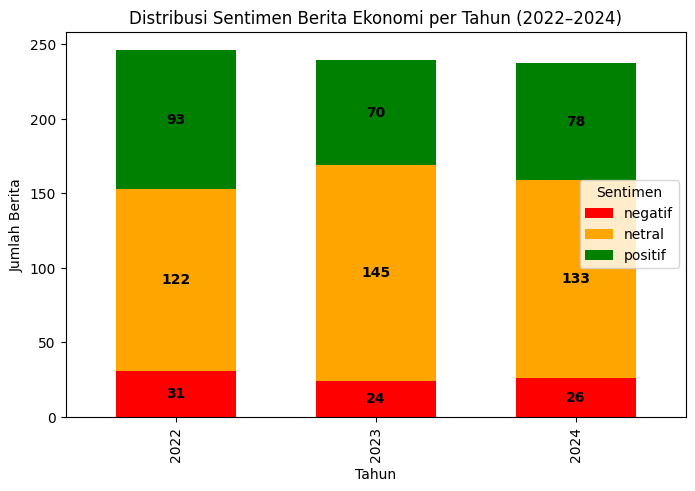

In [ ]:
df_sentimen['tanggal'] = pd.to_datetime(df_sentimen['tanggal'])
df_sentimen['year'] = df_sentimen['tanggal'].dt.year

sentiment_year = (
    df_sentimen
    .groupby([df_sentimen['year'], 'max_impact'])
    .size()
    .unstack()
)

ax = sentiment_year.plot(
    kind='bar',
    stacked=True,
    color=['red', 'orange', 'green'],
    figsize=(8, 5),
    width=0.6
)

plt.xlabel("Tahun")
plt.ylabel("Jumlah Berita")
plt.title("Distribusi Sentimen Berita Ekonomi per Tahun (2022–2024)")
plt.legend(title="Sentimen", loc=0)

for container in ax.containers:
    ax.bar_label(
        container,
        label_type='center',
        fontsize=10,
        fontweight='bold'
    )


plt.show()

In [ ]:
# panjang kata
df['panjang_kata'] = df['konten'].str.split().apply(len)

In [ ]:
print(df['panjang_kata'].describe())

count    1511.000000
mean      338.970218
std       150.625156
min         8.000000
25%       238.500000
50%       306.000000
75%       402.000000
max      1860.000000
Name: panjang_kata, dtype: float64


In [ ]:
# lihat semua berita yang panjangnya kurang dari 10 kata
berita_pendek = df[df['panjang_kata'] < 10]

# tampilkan beberapa baris pertama
print(berita_pendek[['konten', 'panjang_kata']])

                                                konten  panjang_kata
573  Rincian informasinya dirangkum dalam infografi...             8


In [ ]:
# lihat semua berita yang panjangnya kurang dari 10 kata
berita_panjang = df[df['panjang_kata'] > 512]

# tampilkan beberapa baris pertama
print(berita_panjang[['konten', 'panjang_kata']])

                                                 konten  panjang_kata
59    Ketua MPR RI sekaligus Kepala Badan Hubungan P...           874
60    Ketua MPR RI sekaligus Kepala Badan Hubungan P...           842
69    Transformasi Himpunan Bank Milik Negara (Himba...           715
72    Ketua MPR RI Bambang Soesatyo mendorong adanya...           756
74    Ketua MPR RI Bambang Soesatyo (Bamsoet) menduk...           542
...                                                 ...           ...
1489  Laman ekonomi Forbes, seperti biasa telah memb...          1065
1494  Tahukah detikers siapa pemilik Greenfields sek...           524
1495  Catatan ini diungkapkan Ganjar dalam video yan...           720
1501  Presiden Prabowo Subianto memutuskan untuk mem...           594
1503  Perempuan-perempuan ini menekuni bisnis mulai ...           710

[165 rows x 2 columns]


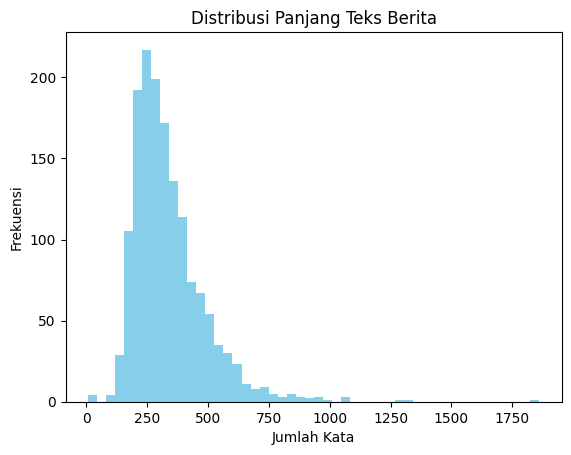

In [ ]:
import matplotlib.pyplot as plt

plt.hist(df['panjang_kata'], bins=50, color='skyblue')
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.title("Distribusi Panjang Teks Berita")
plt.show()

<Axes: xlabel='panjang_kata'>

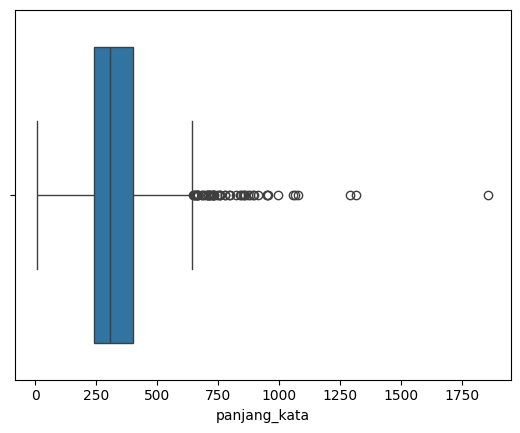

In [ ]:
import seaborn as sns

sns.boxplot(x=df['panjang_kata'])